In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns

import json
import geopandas as gpd

import os

In [576]:
mapping_kecamatan = {
    "ASEMROWO": "ASEM ROWO",
    "DUKUHPAKIS": "DUKUH PAKIS",
    "GUNUNGANYAR": "GUNUNG ANYAR",
    "KARANGPILANG": "KARANG PILANG",
    "LAKARSANTRI": "LAKARSANTRI",
    "MULYOREJO": "MULYOREJO",
    "SAMBIKEREP": "SAMBIKEREP",
    "SUKOLILO": "SUKOLILO",
    "SUKOMANUNGGAL": "SUKOMANUNGGAL",
    "TENGGILISMEJOYO": "TENGGILIS MEJOYO",
    "WIYUNG": "WIYUNG",

    # Nama yang memang sudah sama
    "BENOWO": "BENOWO",
    "PAKAL": "PAKAL",
    "BUBUTAN": "BUBUTAN",
    "BULAK": "BULAK",
    "GAYUNGAN": "GAYUNGAN",
    "GENTENG": "GENTENG",
    "GUBENG": "GUBENG",
    "JAMBANGAN": "JAMBANGAN",
    "KENJERAN": "KENJERAN",
    "KREMBANGAN": "KREMBANGAN",
    "PABEAN CANTIAN": "PABEAN CANTIAN",
    "RUNGKUT": "RUNGKUT",
    "SAWAHAN": "SAWAHAN",
    "SEMAMPIR": "SEMAMPIR",
    "SIMOKERTO": "SIMOKERTO",
    "TAMBAKSARI": "TAMBAKSARI",
    "TANDES": "TANDES",
    "TEGALSARI": "TEGALSARI",
    "WONOCOLO": "WONOCOLO",
    "WONOKROMO": "WONOKROMO"
}

def normalisasi_kecamatan(df, kolom="Kecamatan"):
    df[kolom] = (
        df[kolom]
        .astype(str)
        .str.upper()
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)   # rapikan spasi
    )

    mapping = {
        "ASEMROWO": "ASEM ROWO",
        "DUKUHPAKIS": "DUKUH PAKIS",
        "GUNUNGANYAR": "GUNUNG ANYAR",
        "KARANGPILANG": "KARANG PILANG",
        "TENGGILISMEJOYO": "TENGGILIS MEJOYO"
    }

    df[kolom] = df[kolom].replace(mapping)
    return df

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1, lon1 = radians(lat1), radians(lon1)
    lat2, lon2 = radians(lat2), radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

def idw(df, target_kecamatan, value_col, power=2):

    # lokasi target
    target = df[df["Kecamatan"] == target_kecamatan].iloc[0]

    # hanya data yang diketahui
    known = df[df[value_col].notna()].copy()

    # hitung jarak
    known["distance"] = known.apply(
        lambda row: haversine(
            target["lat"],
            target["long"],
            row["lat"],
            row["long"]
        ),
        axis=1
    )

    # hindari pembagian nol
    known = known[known["distance"] > 0]

    # bobot IDW
    known["weight"] = 1 / (known["distance"] ** power)

    # prediksi
    pred = (
        (known["weight"] * known[value_col]).sum()
        / known["weight"].sum()
    )

    return pred


,No,Kecamatan,lat,long
0,1,KARANG PILANG,-7.341345,112.695990
1,2,WONOCOLO,-7.319820,112.742027
2,3,RUNGKUT,-7.319019,112.804593
3,4,WONOKROMO,-7.303957,112.736011
4,5,TEGALSARI,-7.279848,112.736069


In [745]:
koordinat[koordinat['Kecamatan'] == 'Benowo']

,No,Kecamatan,lat,long
18,19,Benowo,-7.226488,112.649662


In [580]:
koordinat = normalisasi_kecamatan(koordinat)

# X1

In [290]:
folder = "D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X1 Persentase Penduduk Miskin"

for file in os.listdir(folder):
    if file.endswith(".xlsx"):
        tahun = file.split()[-1].replace(".xlsx", "")
        globals()[f"x1_{tahun}"] = pd.read_excel(os.path.join(folder, file))

In [291]:
jumlah_penduduk = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X1 Persentase Penduduk Miskin\jumlah_penduduk_surabaya_per_kecamatan_2023_2025.csv")

In [292]:
#Imputasi Inverse Distance Weighting (IDW)
data = x1_2024.merge(koordinat, on="Kecamatan")
prediksi = idw(
    data,
    target_kecamatan="Tandes",
    value_col="Jumlah (Jiwa)",
    power=2
)

print(prediksi)

2165.438196269988


In [293]:
x1_2024.loc[
    x1_2024["Kecamatan"]=="Tandes",
    "Jumlah (Jiwa)"
] = round(prediksi)

In [321]:
gabungan = []

# Normalisasi data jumlah penduduk cukup sekali
jumlah_penduduk = normalisasi_kecamatan(jumlah_penduduk)

for tahun in range(2023, 2026):
    df = globals()[f"x1_{tahun}"].copy()

    # Format data x1 berbeda
    if tahun == 2023:
        temp = pd.DataFrame({
            "Kecamatan": df.iloc[:, 0],
            "Tahun": tahun,
            "Keluarga Miskin": pd.to_numeric(df.iloc[:, 1], errors="coerce")
        })
    else:
        temp = pd.DataFrame({
            "Kecamatan": df["Kecamatan"],
            "Tahun": tahun,
            "Keluarga Miskin": pd.to_numeric(df["Jumlah (Jiwa)"], errors="coerce")
        })

    # Normalisasi nama kecamatan
    temp = normalisasi_kecamatan(temp)

    # Hapus baris total kota
    temp = temp[
        ~temp["Kecamatan"].isin(["JUMLAH", "KOTA SURABAYA"])
    ].reset_index(drop=True)

    # Merge berdasarkan Kecamatan dan Tahun
    temp = temp.merge(
        jumlah_penduduk,
        on=["Kecamatan", "Tahun"],
        how="left"
    )

    # Hitung rasio
    temp["Rasio Kemiskinan"] = (
        temp["Keluarga Miskin"] /
        temp["Jumlah Penduduk"]
    ) * 100

    gabungan.append(temp)

# Gabungkan seluruh tahun
x1_final = pd.concat(gabungan, ignore_index=True)

# Export
x1_final.to_csv(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X1 Persentase Penduduk Miskin\X1_Rasio_Keluarga_Miskin.csv",
    index=False,
    encoding="utf-8-sig"
)

x1_final.head()

,Kecamatan,Tahun,Keluarga Miskin,Jumlah Penduduk,Rasio Kemiskinan
0,TAMBAKSARI,2023,19654,226995,8.658340
1,WONOKROMO,2023,11973,154995,7.724765
2,SUKOMANUNGGAL,2023,3410,104786,3.254252
3,SEMAMPIR,2023,15171,182371,8.318757
4,GUBENG,2023,9613,133804,7.184389


# X2

In [460]:
folder = "D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X2 Persentase Kepala Keluarga Perempuan"

for file in os.listdir(folder):
    if file.endswith(".xlsx"):
        tahun = file.split()[-1].replace(".xlsx", "")
        globals()[f"x2_{tahun}"] = pd.read_excel(os.path.join(folder, file))

In [448]:
for tahun in range(2023, 2026):
    print(f"===== {tahun} =====")
    print(globals()[f"x2_{tahun}"].columns.tolist())

===== 2023 =====
['No', 'Kecamatan', 'Laki-laki', 'Perempuan', 'Jumlah']
===== 2024 =====
['No', 'Kecamatan', 'Laki-laki', 'Perempuan', 'Jumlah']
===== 2025 =====
['Kecamtan', 'Kepala KeluargaPerempuan', 'Kepala keluarga laki laki']


In [461]:
gabungan = []

for tahun in range(2023, 2026):
    df = globals()[f"x2_{tahun}"].copy()

    if tahun != 2025:
        temp = pd.DataFrame({
            "Kecamatan": df.iloc[:, 1],
            "Tahun": tahun,
            "Rasio Kepala Keluarga Perempuan": df.iloc[:, 3]/(df.iloc[:,2] + df.iloc[:,3])*100
        })
    else:
        temp = pd.DataFrame({
            "Kecamatan": df.iloc[:, 0],
            "Tahun": tahun,
            "Rasio Kepala Keluarga Perempuan": df.iloc[:, 1]/(df.iloc[:,1] + df.iloc[:,2])*100
        })

    # Tambahkan ke list untuk semua tahun
    gabungan.append(temp)

# Gabungkan semua tahun
x2_final = pd.concat(gabungan, ignore_index=True)

x2_final = normalisasi_kecamatan(x2_final)

x2_final = x2_final[
    x2_final["Kecamatan"].str.upper() != "KOTA SURABAYA"
].reset_index(drop=True)

# Export ke CSV
x2_final.to_csv(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X2 Persentase Kepala Keluarga Perempuan\X2_Rasio Kepala Keluarga Perempuan.csv",
    index=False,
    encoding="utf-8-sig"
)
x2_final.head()

,Kecamatan,Tahun,Rasio Kepala Keluarga Perempuan
0,KARANG PILANG,2023,22.031423
1,WONOCOLO,2023,23.825202
2,RUNGKUT,2023,21.401099
3,WONOKROMO,2023,27.068295
4,TEGALSARI,2023,28.310238


# X3

In [429]:
folder = "D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja"

for file in os.listdir(folder):
    if file.endswith(".xlsx"):
        tahun = file.split()[-1].replace(".xlsx", "")
        globals()[f"x3_{tahun}"] = pd.read_excel(os.path.join(folder, file))

In [430]:
gabungan = []

for tahun in range(2023, 2026):

    df = globals()[f"x3_{tahun}"].copy()

    # ==========================
    # Gabungkan header
    # ==========================
    header1 = df.iloc[3].fillna("").astype(str)
    header2 = df.iloc[4].fillna("").astype(str)

    kolom = []

    for h1, h2 in zip(header1, header2):

        h1 = h1.strip()
        h2 = h2.strip()

        if h1 == "":
            kolom.append(h2)
        elif h2 == "":
            kolom.append(h1)
        else:
            kolom.append(f"{h1}_{h2}")

    df.columns = kolom

    # Hapus header
    df = df.iloc[5:].reset_index(drop=True)

    # ==========================
    # Perbaiki kolom PR
    # ==========================
    kolom_baru = []
    nama = None

    for c in df.columns:

        if c.endswith("_LK"):
            nama = c[:-3]
            kolom_baru.append(c)

        elif c == "PR":
            kolom_baru.append(f"{nama}_PR")

        else:
            kolom_baru.append(c)

    df.columns = (
        pd.Index(kolom_baru)
        .str.strip()
        .str.replace(r"\s+", "_", regex=True)
    )

    # ==========================
    # Ambil kecamatan saja
    # ==========================
    df = df[df.iloc[:, 0] == "KECAMATAN"].reset_index(drop=True)

    # Numerik
    for c in df.columns[2:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Hilangkan fragmentation
    df = df.copy()

    # ==========================
    # Tidak bekerja
    # ==========================
    tidak_bekerja = [
        "BELUM_TIDAK_BEKERJA_PR",
        "MENGURUS_RUMAH_TANGGA_PR",
        "PELAJAR_MAHASISWA_PR",
        "PENSIUNAN_PR"
    ]

    # ==========================
    # Seluruh perempuan bekerja
    # ==========================
    bekerja_cols = [
        c for c in df.columns
        if c.endswith("_PR")
        and c not in tidak_bekerja
    ]

    # ==========================
    # Pekerjaan sektor informal
    # ==========================
    informal = [
        "PERDAGANGAN",
        "PETANI_PEKEBUN",
        "PETERNAK",
        "NELAYAN_PERIKANAN",
        "BURUH_HARIAN_LEPAS",
        "BURUH_TANI_PERKEBUNAN",
        "BURUH_NELAYAN_PERIKANAN",
        "BURUH_PETERNAKAN",
        "PEMBANTU_RUMAH_TANGGA",
        "TUKANG_CUKUR",
        "TUKANG_LISTRIK",
        "TUKANG_BATU",
        "TUKANG_KAYU",
        "TUKANG_SOL_SEPATU",
        "TUKANG_LAS_PANDAI_BESI",
        "TUKANG_JAHIT",
        "TUKANG_GIGI",
        "PENATA_RIAS",
        "PENATA_BUSANA",
        "PENATA_RAMBUT",
        "MEKANIK",
        "SENIMAN",
        "TABIB",
        "PARAJI",
        "PERANCANG_BUSANA",
        "PENTERJEMAH",
        "JURU_MASAK",
        "PROMOTOR_ACARA",
        "SOPIR",
        "PARANORMAL",
        "PEDAGANG",
        "WIRASWASTA"
    ]

    informal_cols = [
        c for c in bekerja_cols
        if any(job in c for job in informal)
    ]

    # ==========================
    # Hitung indikator
    # ==========================
    hasil = pd.DataFrame({
        "Perempuan Bekerja": df[bekerja_cols].sum(axis=1),
        "Perempuan Sektor Informal": df[informal_cols].sum(axis=1)
    })

    hasil["Persentase Perempuan Sektor Informal"] = np.where(
        hasil["Perempuan Bekerja"] == 0,
        np.nan,
        hasil["Perempuan Sektor Informal"] /
        hasil["Perempuan Bekerja"] * 100
    )

    temp = pd.concat([
        df["NAMA_KELURAHAN"].rename("Kecamatan"),
        pd.Series(tahun, index=df.index, name="Tahun"),
        hasil
    ], axis=1)

    gabungan.append(temp)

# Gabungkan seluruh tahun
x3_final = pd.concat(gabungan, ignore_index=True)

# Export
x3_final.to_csv(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X3 Persentase Perempuan Bekerja di Sektor Informal\X3_Persentase_Perempuan_Bekerja_di_Sektor_Informal.csv",
    index=False,
    encoding="utf-8-sig"
)

x3_final.head()

,Kecamatan,Tahun,Perempuan Bekerja,Perempuan Sektor Informal,Persentase Perempuan Sektor Informal
0,KARANG PILANG,2023,2037,389,19.096711
1,WONOCOLO,2023,2119,512,24.162341
2,RUNGKUT,2023,3497,712,20.360309
3,WONOKROMO,2023,5221,1105,21.164528
4,TEGALSARI,2023,3236,578,17.861557


# X4

In [363]:
folder = "D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja"

for file in os.listdir(folder):
    if file.endswith(".xlsx"):
        tahun = file.split()[-1].replace(".xlsx", "")
        globals()[f"x4_{tahun}"] = pd.read_excel(os.path.join(folder, file))

In [364]:
gabungan = []

for tahun in range(2023, 2026):

    df = globals()[f"x4_{tahun}"].copy()

    # ==========================
    # Gabungkan header
    # ==========================

    header1 = df.iloc[3].fillna("").astype(str)
    header2 = df.iloc[4].fillna("").astype(str)

    kolom = []

    for h1, h2 in zip(header1, header2):

        h1 = h1.strip()
        h2 = h2.strip()

        if h1 == "":
            kolom.append(h2)

        elif h2 == "":
            kolom.append(h1)

        else:
            kolom.append(f"{h1}_{h2}")

    df.columns = kolom

    # hapus header
    df = df.iloc[5:].reset_index(drop=True)

    # ==========================
    # Rename kolom PR
    # ==========================

    kolom_baru = []

    nama = None

    for c in df.columns:

        if c.endswith("_LK"):
            nama = c[:-3]
            kolom_baru.append(c)

        elif c == "PR":
            kolom_baru.append(f"{nama}_PR")

        else:
            kolom_baru.append(c)

    df.columns = (
        pd.Index(kolom_baru)
        .str.strip()
        .str.replace(r"\s+", "_", regex=True)
    )

    # ==========================
    # Kecamatan saja
    # ==========================

    df = df[df.iloc[:,0].isin(["KECAMATAN"])].reset_index(drop=True)

    # numerik
    for c in df.columns[2:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # ==========================
    # Seluruh pekerjaan perempuan
    # ==========================

    tidak_bekerja = [
        "BELUM_TIDAK_BEKERJA_PR",
        "MENGURUS_RUMAH_TANGGA_PR",
        "PELAJAR_MAHASISWA_PR",
        "PENSIUNAN_PR"
    ]

    bekerja_cols = [
        c
        for c in df.columns
        if c.endswith("_PR")
        and c not in tidak_bekerja
    ]

    df["Perempuan_Bekerja"] = df[bekerja_cols].sum(axis=1)

    temp = df[[
        "NAMA_KELURAHAN",
        "Perempuan_Bekerja"
    ]].copy()

    temp.columns = [
        "Kecamatan",
        "Perempuan_Bekerja"
    ]

    temp["Tahun"] = tahun

    gabungan.append(temp)

x4_final = pd.concat(gabungan, ignore_index=True)


C:\Users\Difta\AppData\Local\Temp\ipykernel_30400\872655877.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Perempuan_Bekerja"] = df[bekerja_cols].sum(axis=1)
C:\Users\Difta\AppData\Local\Temp\ipykernel_30400\872655877.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Perempuan_Bekerja"] = df[bekerja_cols].sum(axis=1)
C:\Users\Difta\AppData\Local\Temp\ipykernel_30400\872655877.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

In [ ]:
jumlah_pdd_2023 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja\Jumlah_Penduduk_Surabaya_Jenis_Kelamin_2023.csv")
jumlah_pdd_2024 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja\Jumlah_Penduduk_Surabaya_Jenis_Kelamin_2024.csv")
jumlah_pdd_2025 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja\Jumlah_Penduduk_Surabaya_Jenis_Kelamin_2025.csv")

In [ ]:
jumlah_pdd_2023["Tahun"] = 2023
jumlah_pdd_2024["Tahun"] = 2024
jumlah_pdd_2025["Tahun"] = 2025

In [368]:
jumlah_perempuan = jumlah_pdd_2023_2025[["Kecamatan", "Tahun", "Perempuan"]].copy()

jumlah_perempuan = jumlah_perempuan.rename(columns={
    "Perempuan": "Jumlah Perempuan"
})

jumlah_perempuan["Kecamatan"] = (
    jumlah_perempuan["Kecamatan"]
    .str.upper()
    .str.strip()
)

jumlah_perempuan

,Kecamatan,Tahun,Jumlah Perempuan
0,GAYUNGAN,2023,22514
1,BULAK,2023,23669
2,ASEM ROWO,2023,23814
3,JAMBANGAN,2023,27373
4,GENTENG,2023,29963
...,...,...,...
88,WONOKROMO,2025,77231
89,SEMAMPIR,2025,90682
90,KENJERAN,2025,92631
91,SAWAHAN,2025,99622


In [369]:
x4_final = x4_final.merge(
    jumlah_perempuan,
    on=["Kecamatan","Tahun"],
    how="left"
)

x4_final["Persentase Perempuan Bekerja"] = (
    x4_final["Perempuan_Bekerja"]
    /
    x4_final["Jumlah Perempuan"]
    *100
)

x4_final.to_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja\X4_Persentase Perempuan Bekerja",
                index=False,
                encoding="utf-8-sig")
x4_final.head()

,Kecamatan,Perempuan_Bekerja,Tahun,Jumlah Perempuan,Persentase Perempuan Bekerja
0,KARANG PILANG,2037,2023,38211,5.330926
1,WONOCOLO,2119,2023,40529,5.228355
2,RUNGKUT,3497,2023,61757,5.662516
3,WONOKROMO,5221,2023,78994,6.609363
4,TEGALSARI,3236,2023,49888,6.486530


# X5

In [495]:
folder = "D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X5 Persentase Perempuan Lulus Wajib Belajar"

for file in os.listdir(folder):
    if file.endswith(".xlsx"):
        tahun = file.split()[-1].replace(".xlsx", "")
        globals()[f"x5_{tahun}"] = pd.read_excel(os.path.join(folder, file))

,KECAMATAN/KELURAHAN,WILAYAH,'TIDAK/BELUM SEKOLAH'_L,'TIDAK/BELUM SEKOLAH'_P,'BELUM TAMAT SD/SEDERAJAT'_L,'BELUM TAMAT SD/SEDERAJAT'_P,'TAMAT SD/SEDERAJAT'_L,'TAMAT SD/SEDERAJAT'_P,'SLTP/SEDERAJAT'_L,'SLTP/SEDERAJAT'_P,...,'DIPLOMA I/II'_L,'DIPLOMA I/II'_P,'AKADEMI/DIPLOMA III/S.MUDA'_L,'AKADEMI/DIPLOMA III/S.MUDA'_P,'DIPLOMA IV/STRATA I'_L,'DIPLOMA IV/STRATA I'_P,'STRATA II'_L,'STRATA II'_P,'STRATA III'_L,'STRATA III'_P
0,KECAMATAN,KARANG PILANG,7716,7240,2222,2161,3347,4369,3504,3819,...,298,414,583,872,4556,4973,368,307,28,18
1,KELURAHAN,KARANG PILANG,809,753,273,304,450,582,451,451,...,15,33,40,94,236,334,12,13,0,0
2,KELURAHAN,KEBRAON,2910,2751,856,766,1038,1401,1158,1322,...,164,195,299,408,2272,2370,186,132,20,6
3,KELURAHAN,KEDURUS,2840,2697,742,761,1215,1526,1253,1390,...,99,154,220,318,1847,2004,161,156,7,11
4,KELURAHAN,WARU GUNUNG,1157,1039,351,330,644,860,642,656,...,20,32,24,52,201,265,9,6,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,KECAMATAN,SAMBIKEREP,6278,6053,2967,2735,4054,5153,3555,4080,...,146,193,481,698,3994,4236,312,220,16,6
180,KELURAHAN,SAMBIKEREP,1828,1739,1057,950,1343,1652,1087,1262,...,51,71,180,258,1433,1573,107,70,8,3
181,KELURAHAN,MADE,855,821,440,396,772,921,581,643,...,11,21,39,51,500,549,39,30,3,1
182,KELURAHAN,BERINGIN,543,506,293,301,401,596,391,423,...,7,2,25,39,181,193,14,10,0,1


In [496]:
gabungan = []

for tahun in range(2023, 2026):

    df = globals()[f"x5_{tahun}"].copy()
    df = df[df.iloc[:, 0] == "KECAMATAN"].reset_index(drop=True)
    df = df.rename(columns={"WILAYAH": "Kecamatan"})
    temp = pd.DataFrame({
        "Kecamatan": df.iloc[:, 1],
        "Tahun": tahun,
        "Perempuan Lulus Wajib Belajar": (
            df.iloc[:, 11] +   # SLTA Perempuan
            df.iloc[:, 13] +   # D1/D2 Perempuan
            df.iloc[:, 15] +   # D3 Perempuan
            df.iloc[:, 17] +   # D4/S1 Perempuan
            df.iloc[:, 19] +   # S2 Perempuan
            df.iloc[:, 21]     # S3 Perempuan
        )
    })

    gabungan.append(temp)

# Gabungkan seluruh tahun
x5_final = pd.concat(gabungan, ignore_index=True)

# Normalisasi nama kecamatan
x5_final = normalisasi_kecamatan(x5_final)
jumlah_perempuan = normalisasi_kecamatan(jumlah_perempuan)

# Merge jumlah perempuan
x5_final = x5_final.merge(
    jumlah_perempuan,
    on=["Kecamatan", "Tahun"],
    how="left"
)

# Hitung persentase
x5_final["Persentase Perempuan Lulus Wajib Belajar"] = (
    x5_final["Perempuan Lulus Wajib Belajar"]
    / x5_final["Jumlah Perempuan"]
) * 100

# Susun kolom
x5_final = x5_final[[
    "Kecamatan",
    "Tahun",
    "Perempuan Lulus Wajib Belajar",
    "Jumlah Perempuan",
    "Persentase Perempuan Lulus Wajib Belajar"
]]

x5_final.to_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X5 Persentase Perempuan Lulus Wajib Belajar\X5_Persentase Perempuan Lulus.csv",
                index=False,
                encoding="utf-8-sig")

x5_final.head()

,Kecamatan,Tahun,Perempuan Lulus Wajib Belajar,Jumlah Perempuan,Persentase Perempuan Lulus Wajib Belajar
0,KARANG PILANG,2023,17950,38211,46.976002
1,WONOCOLO,2023,18533,40529,45.727750
2,RUNGKUT,2023,30390,61757,49.208997
3,WONOKROMO,2023,36421,78994,46.106033
4,TEGALSARI,2023,22314,49888,44.728191


# X6

In [439]:
folder = "D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X6 Dependency Ratio"

for file in os.listdir(folder):
    if file.endswith(".xlsx"):
        tahun = file.split()[-1].replace(".xlsx", "")
        globals()[f"x6_{tahun}"] = pd.read_excel(os.path.join(folder, file))

In [440]:
gabungan = []

for tahun in range(2023, 2026):

    df = globals()[f"x6_{tahun}"].copy()
    
    # Ambil hanya tingkat kecamatan
    df = df[df.iloc[:, 0] == "KECAMATAN"].reset_index(drop=True)
    temp = pd.DataFrame({
        "Kecamatan": df.iloc[:, 1],
        "Tahun": tahun,

        # 0-14 + 65+
        "Penduduk Non Produktif": (
            df.iloc[:, 2] + df.iloc[:, 3] +   # 00-04
            df.iloc[:, 4] + df.iloc[:, 5] +   # 05-09
            df.iloc[:, 6] + df.iloc[:, 7] +   # 10-14
            df.iloc[:, 28] + df.iloc[:, 29] + # 65-69
            df.iloc[:, 30] + df.iloc[:, 31] + # 70-74
            df.iloc[:, 32] + df.iloc[:, 33]   # >75
        ),

        # 15-64
        "Penduduk Produktif": (
            df.iloc[:, 8] + df.iloc[:, 9] +
            df.iloc[:,10] + df.iloc[:,11] +
            df.iloc[:,12] + df.iloc[:,13] +
            df.iloc[:,14] + df.iloc[:,15] +
            df.iloc[:,16] + df.iloc[:,17] +
            df.iloc[:,18] + df.iloc[:,19] +
            df.iloc[:,20] + df.iloc[:,21] +
            df.iloc[:,22] + df.iloc[:,23] +
            df.iloc[:,24] + df.iloc[:,25] +
            df.iloc[:,26] + df.iloc[:,27]
        )
    })

    gabungan.append(temp)

# Gabungkan semua tahun
x6_final = pd.concat(gabungan, ignore_index=True)

# Normalisasi nama kecamatan
x6_final = normalisasi_kecamatan(x6_final)

# Hitung Dependency Ratio
x6_final["Dependency Ratio"] = (
    x6_final["Penduduk Non Produktif"] /
    x6_final["Penduduk Produktif"]
) * 100

# Susun kolom
x6_final = x6_final[[
    "Kecamatan",
    "Tahun",
    "Penduduk Non Produktif",
    "Penduduk Produktif",
    "Dependency Ratio"
]]

# Export
x6_final.to_csv(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X6 Dependency Ratio\X6_Dependency_Ratio.csv",
    index=False,
    encoding="utf-8-sig"
)

x6_final.head()

,Kecamatan,Tahun,Penduduk Non Produktif,Penduduk Produktif,Dependency Ratio
0,KARANG PILANG,2023,21817,53755,40.585992
1,WONOCOLO,2023,23986,56000,42.832143
2,RUNGKUT,2023,35561,86380,41.168094
3,WONOKROMO,2023,44369,110626,40.107208
4,TEGALSARI,2023,29428,68889,42.717996


In [497]:
for i in range(1, 7):
    df = globals()[f"x{i}_final"]

    print(f"\n===== x{i}_final =====")
    print(df.isnull().sum())


===== x1_final =====
Kecamatan           0
Tahun               0
Keluarga Miskin     0
Jumlah Penduduk     0
Rasio Kemiskinan    0
dtype: int64

===== x2_final =====
Kecamatan                          0
Tahun                              0
Rasio Kepala Keluarga Perempuan    0
dtype: int64

===== x3_final =====
Kecamatan                               0
Tahun                                   0
Perempuan Bekerja                       0
Perempuan Sektor Informal               0
Persentase Perempuan Sektor Informal    0
dtype: int64

===== x4_final =====
Kecamatan                       0
Perempuan_Bekerja               0
Tahun                           0
Jumlah Perempuan                0
Persentase Perempuan Bekerja    0
dtype: int64

===== x5_final =====
Kecamatan                                   0
Tahun                                       0
Perempuan Lulus Wajib Belajar               0
Jumlah Perempuan                            0
Persentase Perempuan Lulus Wajib Belajar    0
dtype: 

In [498]:
for i in range(1, 7):
    df = globals()[f"x{i}_final"]

    print(f"\n===== x{i}_final =====")
    print(df.groupby("Tahun")["Kecamatan"].nunique())


===== x1_final =====
Tahun
2023    31
2024    31
2025    31
Name: Kecamatan, dtype: int64

===== x2_final =====
Tahun
2023    31
2024    31
2025    31
Name: Kecamatan, dtype: int64

===== x3_final =====
Tahun
2023    31
2024    31
2025    31
Name: Kecamatan, dtype: int64

===== x4_final =====
Tahun
2023    31
2024    31
2025    31
Name: Kecamatan, dtype: int64

===== x5_final =====
Tahun
2023    31
2024    31
2025    31
Name: Kecamatan, dtype: int64

===== x6_final =====
Tahun
2023    31
2024    31
2025    31
Name: Kecamatan, dtype: int64


In [499]:
for i in range(2, 7):
    beda = (
        set(x1_final["Kecamatan"])
        ^ set(globals()[f"x{i}_final"]["Kecamatan"])
    )

    print(f"x{i}:", beda)

x2: set()
x3: set()
x4: set()
x5: set()
x6: set()


In [500]:
for i in range(1, 7):

    df = globals()[f"x{i}_final"]

    dup = df.duplicated(["Kecamatan","Tahun"]).sum()

    print(f"x{i} : {dup}")

x1 : 0
x2 : 0
x3 : 0
x4 : 0
x5 : 0
x6 : 0


In [501]:
for i in range(1,7):
    print(i, len(globals()[f"x{i}_final"]))

1 93
2 93
3 93
4 93
5 93
6 93


In [502]:
for i in range(1,7):

    df = globals()[f"x{i}_final"]

    print(f"\nx{i}")

    print((df.select_dtypes("number") < 0).sum())


x1
Tahun               0
Keluarga Miskin     0
Jumlah Penduduk     0
Rasio Kemiskinan    0
dtype: int64

x2
Tahun                              0
Rasio Kepala Keluarga Perempuan    0
dtype: int64

x3
Tahun                                   0
Perempuan Bekerja                       0
Perempuan Sektor Informal               0
Persentase Perempuan Sektor Informal    0
dtype: int64

x4
Perempuan_Bekerja               0
Tahun                           0
Jumlah Perempuan                0
Persentase Perempuan Bekerja    0
dtype: int64

x5
Tahun                                       0
Perempuan Lulus Wajib Belajar               0
Jumlah Perempuan                            0
Persentase Perempuan Lulus Wajib Belajar    0
dtype: int64

x6
Tahun                     0
Penduduk Non Produktif    0
Penduduk Produktif        0
Dependency Ratio          0
dtype: int64


In [503]:
persentase = {
    "x1_final":"Rasio Kemiskinan",
    "x2_final":"Rasio Kepala Keluarga Perempuan",
    "x3_final":"Persentase Perempuan Sektor Informal",
    "x4_final":"Persentase Perempuan Bekerja",
    "x5_final":"Persentase Perempuan Lulus Wajib Belajar",
}

for nama, kolom in persentase.items():

    df = globals()[nama]

    print(nama)
    print(df[kolom].min(), df[kolom].max())

x1_final
0.002197826349740107 14.078399785206066
x2_final
18.675968680987754 30.411325050735037
x3_final
17.762237762237763 42.55842558425584
x4_final
2.9311219426126462 7.306462679376943
x5_final
18.854116302580106 58.893884892086334


In [504]:
x6_final["Dependency Ratio"].describe()

count    93.000000
mean     42.218510
std       1.928982
min      38.671453
25%      40.949170
50%      42.229555
75%      43.150054
max      46.865052
Name: Dependency Ratio, dtype: float64

In [505]:
X1 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X1 Persentase Penduduk Miskin\X1_Rasio_Keluarga_Miskin.csv")
X2 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X2 Persentase Kepala Keluarga Perempuan\X2_Rasio Kepala Keluarga Perempuan.csv")
X3 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X3 Persentase Perempuan Bekerja di Sektor Informal\X3_Persentase_Perempuan_Bekerja_di_Sektor_Informal.csv")
X4 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X4 Persentase perempuan yang bekerja\X4_Persentase Perempuan Bekerja")
X5 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X5 Persentase Perempuan Lulus Wajib Belajar\X5_Persentase Perempuan Lulus.csv")
X6 = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\X6 Dependency Ratio\X6_Dependency_Ratio.csv")

In [520]:
final_df = (
    X1[["Kecamatan", "Tahun", "Rasio Kemiskinan"]]
    .merge(
        X2[["Kecamatan", "Tahun", "Rasio Kepala Keluarga Perempuan"]],
        on=["Kecamatan", "Tahun"]
    )
    .merge(
        X3[["Kecamatan", "Tahun", "Persentase Perempuan Sektor Informal"]],
        on=["Kecamatan", "Tahun"]
    )
    .merge(
        X4[["Kecamatan", "Tahun", "Persentase Perempuan Bekerja"]],
        on=["Kecamatan", "Tahun"]
    )
    .merge(
        X5[["Kecamatan", "Tahun", "Persentase Perempuan Lulus Wajib Belajar"]],
        on=["Kecamatan", "Tahun"]
    )
    .merge(
        X6[["Kecamatan", "Tahun", "Dependency Ratio"]],
        on=["Kecamatan", "Tahun"]
    )
)

final_df = final_df.rename(columns={
    "Rasio Kemiskinan": "X1",
    "Rasio Kepala Keluarga Perempuan": "X2",
    "Persentase Perempuan Sektor Informal": "X3",
    "Persentase Perempuan Bekerja": "X4",
    "Persentase Perempuan Lulus Wajib Belajar": "X5",
    "Dependency Ratio": "X6"
})

final_df.to_csv(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\final_df.csv",
    index=False,
    encoding="utf-8-sig"
)

final_df.head()

,Kecamatan,Tahun,X1,X2,X3,X4,X5,X6
0,TAMBAKSARI,2023,8.658340,25.552954,22.452616,5.376335,36.664983,42.349636
1,WONOKROMO,2023,7.724765,27.068295,21.164528,6.609363,46.106033,40.107208
2,SUKOMANUNGGAL,2023,3.254252,22.681790,27.445067,4.399500,40.948897,43.042796
3,SEMAMPIR,2023,8.318757,25.608862,38.582090,2.944925,18.854116,46.831825
4,GUBENG,2023,7.184389,27.359966,17.762238,7.306463,49.048919,42.478065


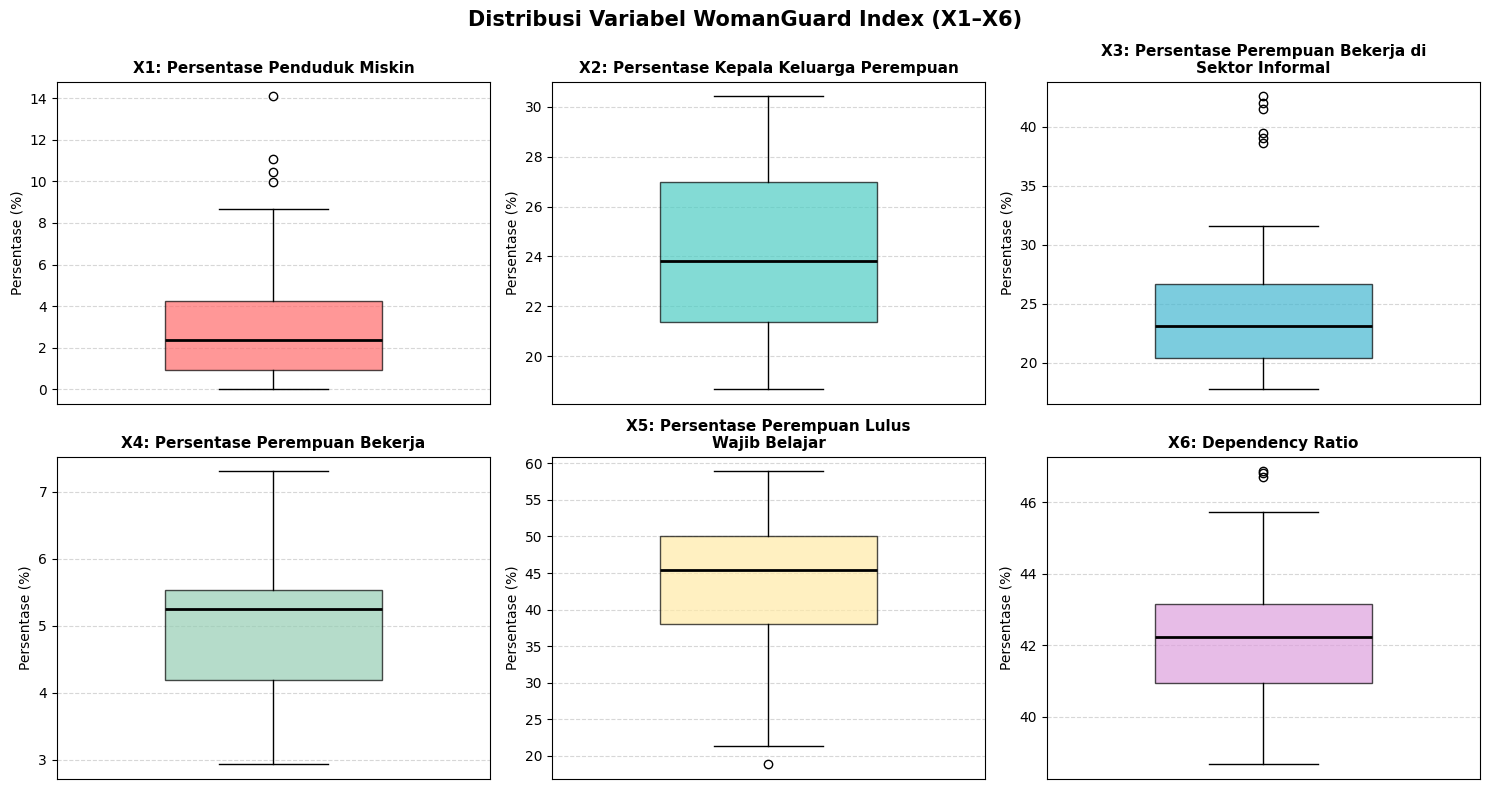

X1
Jumlah outlier : 4

X2
Jumlah outlier : 0

X3
Jumlah outlier : 6

X4
Jumlah outlier : 0

X5
Jumlah outlier : 1

X6
Jumlah outlier : 3



In [524]:
# Visualisasi boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Nama kolom pada final_df
columns = [
    "X1",
    "X2",
    "X3",
    "X4",
    "X5",
    "X6"
]

# Judul
titles = [
    "X1: Persentase Penduduk Miskin",
    "X2: Persentase Kepala Keluarga Perempuan",
    "X3: Persentase Perempuan Bekerja di\nSektor Informal",
    "X4: Persentase Perempuan Bekerja",
    "X5: Persentase Perempuan Lulus\nWajib Belajar",
    "X6: Dependency Ratio"
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1',
          '#96CEB4', '#FFEAA7', '#DDA0DD']

for ax, col, title, color in zip(axes, columns, titles, colors):

    bp = ax.boxplot(
        final_df[col],
        patch_artist=True,
        widths=0.5
    )

    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)

    bp['medians'][0].set_color('black')
    bp['medians'][0].set_linewidth(2)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Persentase (%)", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks([])

plt.suptitle(
    "Distribusi Variabel WomanGuard Index (X1–X6)",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\Visualisasi\Boxplot_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

for col in ["X1","X2","X3","X4","X5","X6"]:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = final_df[(final_df[col] < lower) | (final_df[col] > upper)]

    print(f"{col}")
    print("Jumlah outlier :", len(outlier))
    print()

In [525]:
for col in ["X1","X2","X3","X4","X5","X6"]:

    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = final_df[
        (final_df[col] < lower) |
        (final_df[col] > upper)
    ]

    print("="*60)
    print(col)

    print(outlier[[
        "Kecamatan",
        "Tahun",
        col
    ]])

X1
         Kecamatan  Tahun         X1
5        SIMOKERTO   2023  10.450676
7        TEGALSARI   2023  11.068279
8       KREMBANGAN   2023   9.982657
14  PABEAN CANTIAN   2023  14.078400
X2
Empty DataFrame
Columns: [Kecamatan, Tahun, X2]
Index: []
X3
    Kecamatan  Tahun         X3
3    SEMAMPIR   2023  38.582090
18  ASEM ROWO   2023  41.521197
31  ASEM ROWO   2024  42.558426
51   SEMAMPIR   2024  39.461056
62  ASEM ROWO   2025  41.979950
82   SEMAMPIR   2025  39.014296
X4
Empty DataFrame
Columns: [Kecamatan, Tahun, X4]
Index: []
X5
  Kecamatan  Tahun         X5
3  SEMAMPIR   2023  18.854116
X6
   Kecamatan  Tahun         X6
3   SEMAMPIR   2023  46.831825
51  SEMAMPIR   2024  46.705245
82  SEMAMPIR   2025  46.865052


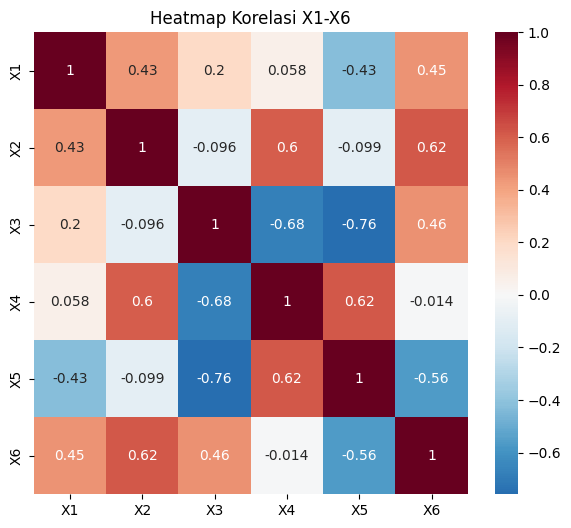

In [528]:
corr = final_df[
    ["X1","X2","X3","X4","X5","X6"]
].corr()

plt.figure(figsize=(7,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Heatmap Korelasi X1-X6")
plt.savefig(
    r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\Visualisasi\Heatmap_Korelasi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [530]:
from factor_analyzer.factor_analyzer import (
    calculate_kmo,
    calculate_bartlett_sphericity
)

chi_square, p = calculate_bartlett_sphericity(
    final_df[["X1","X2","X3","X4","X5","X6"]]
)

kmo_all, kmo_model = calculate_kmo(
    final_df[["X1","X2","X3","X4","X5","X6"]]
)

print("Bartlett p-value :", p)
print("KMO :", kmo_model)

Bartlett p-value : 5.59692360059813e-75
KMO : 0.6528346910000056


In [531]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Z = pd.DataFrame(
    scaler.fit_transform(final_df[["X1","X2","X3","X4","X5","X6"]]),
    columns=["X1","X2","X3","X4","X5","X6"]
)

# Balik arah indikator positif
Z["X4"] *= -1
Z["X5"] *= -1

In [844]:
pca = PCA()

# step 1: fit dulu untuk analisis
pca.fit(Z)

# step 2: ambil loading & eigenvalue
loadings = pca.components_
eigenvalues = pca.explained_variance_

# step 3: baru transform untuk WGI
Z_pca = pca.transform(Z)
# WGI = Z_pca[:, 0]

In [860]:
# PCA
pca = PCA()
Z_pca = pca.fit_transform(Z)

# Tampilkan hasil
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print(f"\nTotal Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")

# Buat dataframe hasil PCA
pca_df = pd.DataFrame(Z_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])
pca_df['Kecamatan'] = final_df['Kecamatan']
pca_df['Tahun'] = final_df['Tahun']

pca_df

Explained Variance Ratio:
[0.46222673 0.35306352 0.10379707 0.03563775 0.03226015 0.01301478]

Total Explained Variance: 1.0000


,PC1,PC2,PC3,PC4,PC5,PC6,Kecamatan,Tahun
0,0.849289,1.182351,1.578327,-0.280993,-0.159393,-0.151874,tambaksari,2023
1,-0.819055,1.695015,1.595528,0.424043,-0.963068,-0.103269,wonokromo,2023
2,0.817651,-0.581481,-0.119535,0.140739,0.350956,0.001475,sukomanunggal,2023
3,5.253872,-0.036177,0.108635,0.062046,0.293392,0.135891,semampir,2023
4,-1.065135,2.644134,0.976966,0.166890,0.005638,-0.490457,gubeng,2023
...,...,...,...,...,...,...,...,...
88,-0.907791,2.456688,0.409790,-0.066767,-0.023393,0.370682,tegalsari,2025
89,-1.413896,-0.266021,-0.658871,0.390499,0.142253,0.125186,tenggilismejoyo,2025
90,-2.074606,-1.483659,0.394837,0.004985,-0.144343,0.271190,wiyung,2025
91,-0.567456,0.083601,-0.061751,0.622938,0.221303,0.378966,wonocolo,2025


In [861]:
WGI = (
    0.46222673 * Z_pca[:, 0] +
    0.35306352 * Z_pca[:, 1]
)
pca_df['WGI'] = -WGI

In [857]:
len(pca_df)

93

In [848]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,Kecamatan,Tahun,WGI
0,0.849289,1.182351,1.578327,-0.280993,-0.159393,-0.151874,TAMBAKSARI,2023,-0.810009
1,-0.819055,1.695015,1.595528,0.424043,-0.963068,-0.103269,WONOKROMO,2023,-0.219859
2,0.817651,-0.581481,-0.119535,0.140739,0.350956,0.001475,SUKOMANUNGGAL,2023,-0.172640
3,5.253872,-0.036177,0.108635,0.062046,0.293392,0.135891,SEMAMPIR,2023,-2.415708
4,-1.065135,2.644134,0.976966,0.166890,0.005638,-0.490457,GUBENG,2023,-0.441213
...,...,...,...,...,...,...,...,...,...
88,-0.907791,2.456688,0.409790,-0.066767,-0.023393,0.370682,TEGALSARI,2025,-0.447762
89,-1.413896,-0.266021,-0.658871,0.390499,0.142253,0.125186,TENGGILIS MEJOYO,2025,0.747463
90,-2.074606,-1.483659,0.394837,0.004985,-0.144343,0.271190,WIYUNG,2025,1.482764
91,-0.567456,0.083601,-0.061751,0.622938,0.221303,0.378966,WONOCOLO,2025,0.232777


In [862]:
# 1. Bersihkan spasi dan normalkan teks di semua DataFrame sumber
pca_df['Kecamatan'] = pca_df['Kecamatan'].astype(str).str.replace(" ", "").str.lower()
final_df['Kecamatan'] = final_df['Kecamatan'].astype(str).str.replace(" ", "").str.lower()
koordinat['Kecamatan'] = koordinat['Kecamatan'].astype(str).str.replace(" ", "").str.lower()

# 2. Lakukan proses merge dengan aman
pca_df = pca_df.merge(final_df, on=["Kecamatan", "Tahun"], how='left') \
               .merge(koordinat, on='Kecamatan', how='left')

# 3. Tampilkan hasil akhir
pca_df
pca_df.to_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\pca_df.csv", index=False)

In [863]:
# Menampilkan baris yang memiliki minimal satu nilai kosong di kolom mana pun
pca_df[pca_df.isnull().any(axis=1)]

,PC1,PC2,PC3,PC4,PC5,PC6,Kecamatan,Tahun,WGI,X1,X2,X3,X4,X5,X6,No,lat,long


In [746]:
#Load GeoDataFrame kecamatan Surabaya
with open('D:\KULIAH\Project\womanguard-index-surabaya\data\gadm41_IDN_4.json', 'r') as f:
    data = json.load(f)

surabaya_features = [
    f for f in data['features']
    if 'Surabaya' in str(f['properties'].get('NAME_2', ''))
]

gdf = gpd.GeoDataFrame.from_features(surabaya_features, crs='EPSG:4326')

In [751]:
kec_gdf = gdf.dissolve(by='NAME_3').reset_index()
gdf_meter = kec_gdf.to_crs(epsg=32749)   # UTM Zone 49S (Surabaya)
gdf_meter["centroid"] = gdf_meter.geometry.centroid
centroid = (
    gdf_meter
    .set_geometry("centroid")
    .to_crs(epsg=4326)
)
centroid["long"] = centroid.geometry.x
centroid["lat"] = centroid.geometry.y
koordinat = centroid[["NAME_3", "long", "lat"]].copy()

koordinat.rename(columns={
    "NAME_3": "Kecamatan"
}, inplace=True)

koordinat = normalisasi_kecamatan(koordinat)

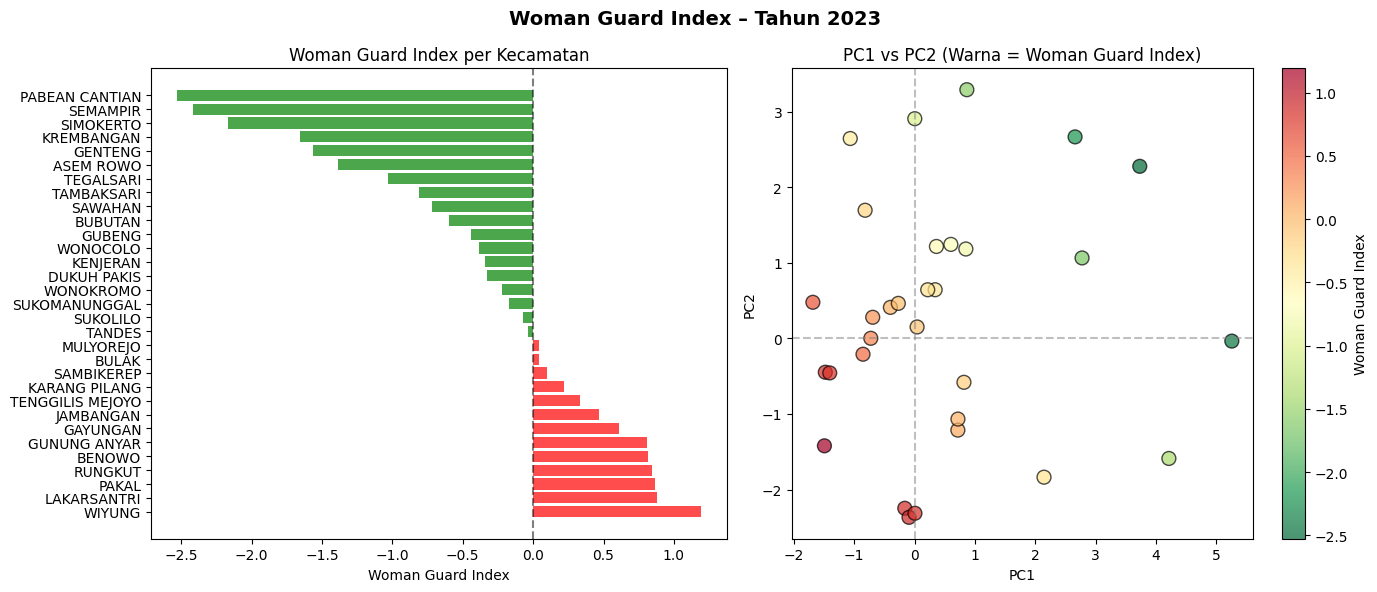


Statistik Woman Guard Index – Tahun 2023
Max : 1.1920 (WIYUNG)
Min : -2.5275 (PABEAN CANTIAN)
Mean: -0.3112
Std : 1.0002


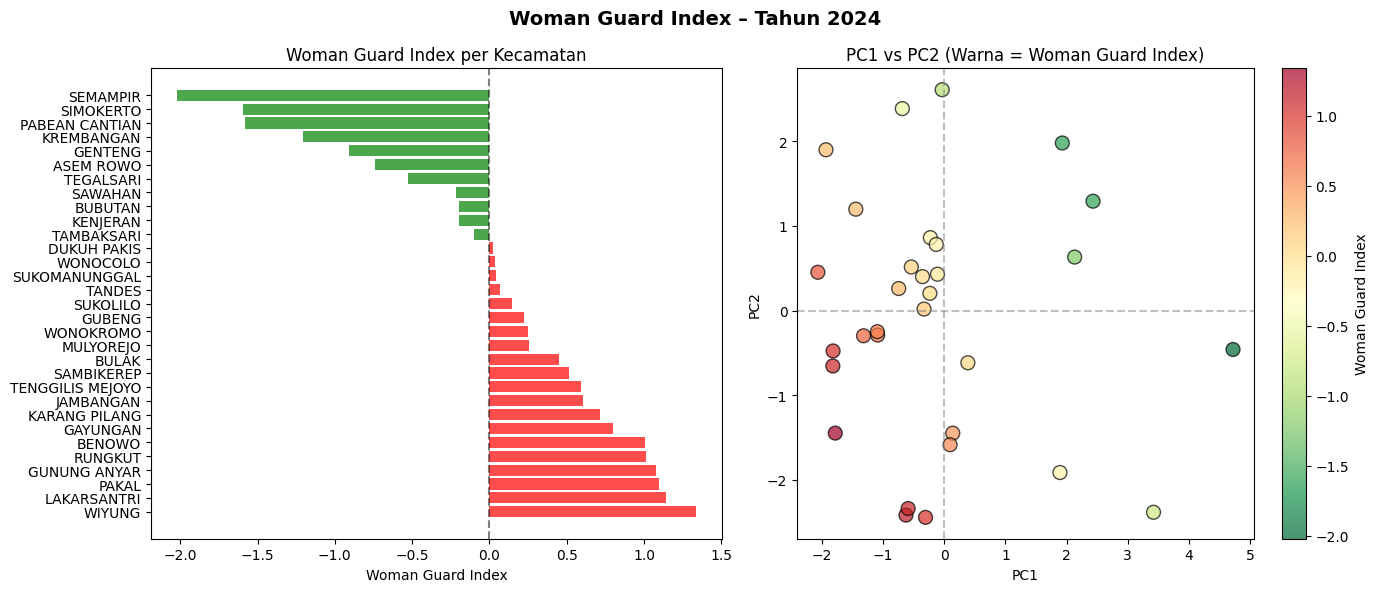


Statistik Woman Guard Index – Tahun 2024
Max : 1.3370 (WIYUNG)
Min : -2.0208 (SEMAMPIR)
Mean: 0.0682
Std : 0.8613


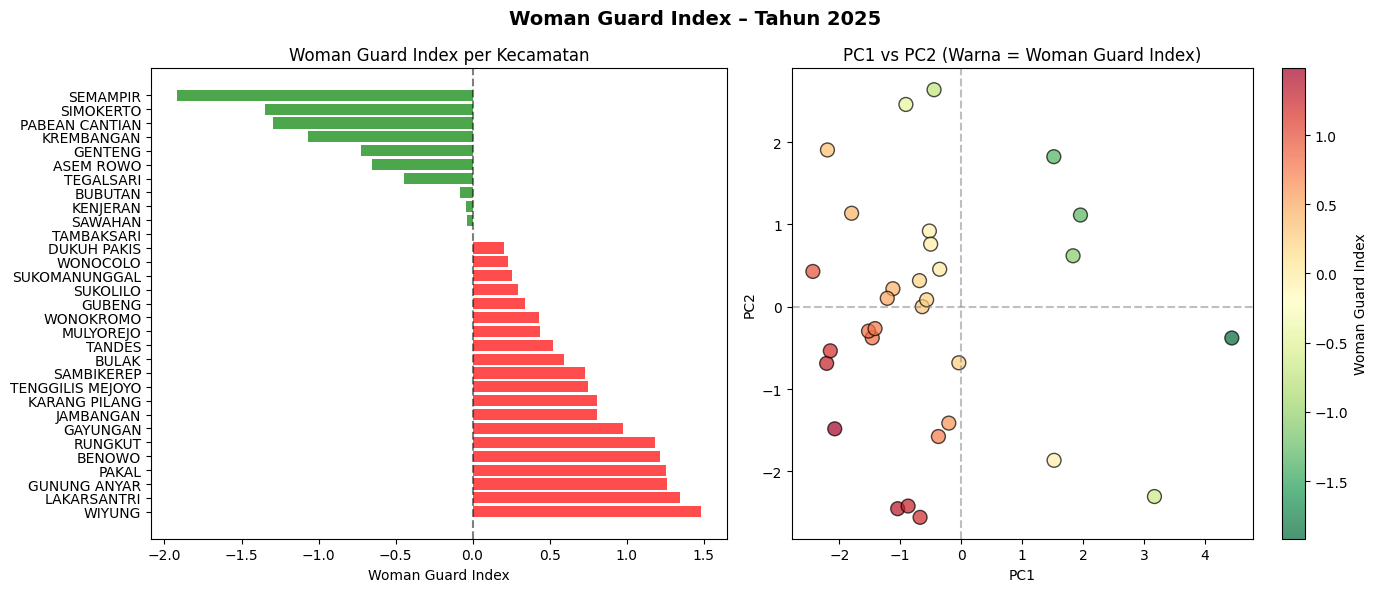


Statistik Woman Guard Index – Tahun 2025
Max : 1.4828 (WIYUNG)
Min : -1.9169 (SEMAMPIR)
Mean: 0.2430
Std : 0.8645


In [668]:
import os

# Pastikan kolom 'Tahun' ada di pca_df
# Jika tidak ada, sesuaikan nama kolomnya

tahun_list = sorted(pca_df['Tahun'].unique())

for tahun in tahun_list:
    df_tahun = pca_df[pca_df['Tahun'] == tahun].copy()

    # ── Visualisasi ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Woman Guard Index – Tahun {tahun}', fontsize=14, fontweight='bold')

    # Plot 1: Bar chart WGI per Kecamatan
    ax1 = axes[0]
    sorted_df = df_tahun.sort_values('WGI', ascending=False)
    colors = ['red' if x > 0 else 'green' for x in sorted_df['WGI']]
    ax1.barh(sorted_df['Kecamatan'], sorted_df['WGI'], color=colors, alpha=0.7)
    ax1.set_xlabel('Woman Guard Index')
    ax1.set_title('Woman Guard Index per Kecamatan')
    ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)

    # Plot 2: Scatter PC1 vs PC2
    ax2 = axes[1]
    scatter = ax2.scatter(
        df_tahun['PC1'], df_tahun['PC2'],
        c=df_tahun['WGI'], cmap='RdYlGn_r',
        s=100, alpha=0.7, edgecolors='black'
    )
    fig.colorbar(scatter, ax=ax2, label='Woman Guard Index')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_title('PC1 vs PC2 (Warna = Woman Guard Index)')
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()

    # Simpan per tahun
    save_dir = r"D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\Visualisasi"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"Woman_Guard_Index_{tahun}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()

    # ── Statistik ─────────────────────────────────────────────────
    print(f"\n{'='*45}")
    print(f"Statistik Woman Guard Index – Tahun {tahun}")
    print(f"{'='*45}")
    print(f"Max : {df_tahun['WGI'].max():.4f} ({df_tahun.loc[df_tahun['WGI'].idxmax(), 'Kecamatan']})")
    print(f"Min : {df_tahun['WGI'].min():.4f} ({df_tahun.loc[df_tahun['WGI'].idxmin(), 'Kecamatan']})")
    print(f"Mean: {df_tahun['WGI'].mean():.4f}")
    print(f"Std : {df_tahun['WGI'].std():.4f}")

In [864]:
df = pca_df.copy()
df = df.dropna(subset=['long', 'lat', 'WGI'])

# 1. Time encoding (dihitung berbasis seluruh dataframe, bukan per tahun)
df['time'] = df['Tahun'] - df['Tahun'].min()

# 2. Extract targets and features
y = df['WGI'].values.reshape(-1, 1)
X = df[['PC1', 'PC2']].values

# 3. Ambil koordinat spasial
spatial_coords = df[['long', 'lat']].values

# 4. Ambil dan Scale kolom 'time' secara terpisah
scaler = StandardScaler()
scaled_time = scaler.fit_transform(df[['time']].values)

# 5. Gabungkan menjadi satu array matriks 3D (long, lat, scaled_time)
coords = np.hstack([spatial_coords, scaled_time])

In [865]:
results_all = []

for year in df['Tahun'].unique():
    # 1. Saring data per tahun
    df_year = df[df['Tahun'] == year].copy()
    
    # 2. Koordinat HANYA menggunakan spatial (long, lat)
    coords = df_year[['long', 'lat']].values
    
    y = df_year['WGI'].values.reshape(-1, 1)
    X = df_year[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']].values
    
    n_samples = len(df_year)
    if n_samples < 30: # Jaga-jaga agar data tidak kekecilan untuk menghindari R2 = 1
        continue
        
    # 3. Gunakan fixed=False (Adaptive) agar jumlah tetangga stabil dan tidak overfit
    selector = Sel_BW(coords, y, X, fixed=False, kernel='bisquare')
    bw = selector.search(bw_min=2, bw_max=20)
    
    model = GWR(coords, y, X, bw, fixed=False, kernel='bisquare')
    res = model.fit()
    
    # 4. Simpan hasil prediksi dan koefisien lokal
    df_year['WGI_pred'] = res.predy.flatten()
    
    # Menyimpan nilai beta untuk tiap PC agar bisa diinterpretasikan nanti
    df_year['beta_PC1'] = res.params[:, 1]
    df_year['beta_PC2'] = res.params[:, 2]
    
    results_all.append(df_year)

# Gabungkan kembali semua tahun
gwr_final_df = pd.concat(results_all, ignore_index=True)

LinAlgError: A singular matrix detected: slice(s) [0] are singular.

In [866]:
import pandas as pd
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# Asumsi df sudah bersih dan koordinat spasial sudah siap
# Kita coba jalankan ke SELURUH data (tanpa loop per tahun) untuk melihat kestabilannya

coords = pca_df[['long', 'lat']].values
y = pca_df['WGI'].values.reshape(-1, 1)
X = pca_df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']].values

# Gunakan adaptive bandwidth (fixed=False)
selector = Sel_BW(coords, y, X, fixed=False, kernel='bisquare')

# Biarkan algoritma mencari bandwidth optimal berbasis AICc
bw = selector.search()
print(f"Bandwidth Optimal Terpilih: {bw} tetangga")

model = GWR(coords, y, X, bw, fixed=False, kernel='bisquare')
res = model.fit()

# AMBIL R-SQUARED RESMI DARI MODEL GWR
print(f"R2 Global GWR Resmi: {res.R2:.4f}")
print(f"Adjusted R2 GWR Resmi: {res.adj_R2:.4f}")

Bandwidth Optimal Terpilih: 68.0 tetangga
R2 Global GWR Resmi: 1.0000
Adjusted R2 GWR Resmi: 1.0000


In [842]:
# Menampilkan baris yang memiliki minimal satu nilai kosong di kolom mana pun
pca_df[pca_df.isnull().any(axis=1)]

,PC1,PC2,PC3,PC4,PC5,PC6,Kecamatan,Tahun,WGI,X1,X2,X3,X4,X5,X6,long,lat
14,3.729502,2.276147,1.980028,0.632450,0.337826,0.282789,PABEAN CANTIAN,2023,-2.527500,14.078400,28.361165,31.611454,4.737962,30.917797,45.616264,NaN,NaN
46,2.432680,1.293162,-0.683977,0.186385,-0.215851,0.295652,PABEAN CANTIAN,2024,-1.581018,5.053361,28.918480,31.218698,4.824291,33.574056,45.293216,NaN,NaN
77,1.955227,1.113514,-1.002538,0.372608,-0.251187,0.603111,PABEAN CANTIAN,2025,-1.296899,3.806634,29.177169,31.203224,4.750834,37.982058,44.879608,NaN,NaN


In [829]:
gwr_final_df.to_csv("D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\gwr_df.csv", index=False)

In [830]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

# 1. Muat data hasil GWR Anda
gwr_final_df = pd.read_csv('D:\KULIAH\Project\womanguard-index-surabaya\Data terbaru dip\gwr_df.csv')

# 2. Ambil nilai aktual dan nilai prediksi
y_true = gwr_final_df['WGI'].values
y_pred = gwr_final_df['WGI_pred'].values

# 3. Hitung R-squared Global
r2_global = r2_score(y_true, y_pred)

print(f"R-squared Global Model GWR: {r2_global:.4f}")

R-squared Global Model GWR: 1.0000


In [813]:
for year in gtwr_df['Tahun'].unique():
    df_year = gtwr_df[gtwr_df['Tahun'] == year]
    r2_year = r2_score(df_year['WGI'], df_year['WGI_pred'])
    print(f"R-squared Tahun {year}: {r2_year:.4f}")

R-squared Tahun 2023: 1.0000
R-squared Tahun 2024: 1.0000
R-squared Tahun 2025: 1.0000


In [814]:
gtwr_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,Kecamatan,Tahun,WGI,X1,...,No,lat,long,WGI_pred,beta_PC1,beta_PC2,beta_PC3,beta_PC4,beta_PC5,beta_PC6
0,0.849289,1.182351,1.578327,-0.280993,-0.159393,-0.151874,TAMBAKSARI,2023,-0.810009,8.658340,...,10,-7.250445,112.768842,-0.810009,-0.462227,-0.353064,-4.510281e-17,6.245005e-17,-2.081668e-17,5.447032e-16
1,-0.819055,1.695015,1.595528,0.424043,-0.963068,-0.103269,WONOKROMO,2023,-0.219859,7.724765,...,4,-7.303957,112.736011,-0.219859,-0.462227,-0.353064,5.481726e-16,-1.144917e-16,2.289835e-16,-1.415534e-15
2,0.817651,-0.581481,-0.119535,0.140739,0.350956,0.001475,SUKOMANUNGGAL,2023,-0.172640,3.254252,...,27,-7.264818,112.697270,-0.172640,-0.462227,-0.353064,-2.567391e-16,4.232725e-16,-2.359224e-16,1.026956e-15
3,5.253872,-0.036177,0.108635,0.062046,0.293392,0.135891,SEMAMPIR,2023,-2.415708,8.318757,...,16,-7.211455,112.745007,-2.415708,-0.462227,-0.353064,4.319461e-16,1.144917e-16,4.302114e-16,-2.220446e-16
4,-1.065135,2.644134,0.976966,0.166890,0.005638,-0.490457,GUBENG,2023,-0.441213,7.184389,...,8,-7.278906,112.753945,-0.441213,-0.462227,-0.353064,2.081668e-16,8.673617e-17,-6.938894e-18,1.110223e-16


In [817]:
gwr_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,Kecamatan,Tahun,WGI,X1,...,No,lat,long,WGI_pred,beta_PC1,beta_PC2,beta_PC3,beta_PC4,beta_PC5,beta_PC6
0,0.849289,1.182351,1.578327,-0.280993,-0.159393,-0.151874,TAMBAKSARI,2023,-0.810009,8.658340,...,10,-7.250445,112.768842,-0.810009,-0.462227,-0.353064,-4.510281e-17,6.245005e-17,-2.081668e-17,5.447032e-16
1,-0.819055,1.695015,1.595528,0.424043,-0.963068,-0.103269,WONOKROMO,2023,-0.219859,7.724765,...,4,-7.303957,112.736011,-0.219859,-0.462227,-0.353064,5.481726e-16,-1.144917e-16,2.289835e-16,-1.415534e-15
2,0.817651,-0.581481,-0.119535,0.140739,0.350956,0.001475,SUKOMANUNGGAL,2023,-0.172640,3.254252,...,27,-7.264818,112.697270,-0.172640,-0.462227,-0.353064,-2.567391e-16,4.232725e-16,-2.359224e-16,1.026956e-15
3,5.253872,-0.036177,0.108635,0.062046,0.293392,0.135891,SEMAMPIR,2023,-2.415708,8.318757,...,16,-7.211455,112.745007,-2.415708,-0.462227,-0.353064,4.319461e-16,1.144917e-16,4.302114e-16,-2.220446e-16
4,-1.065135,2.644134,0.976966,0.166890,0.005638,-0.490457,GUBENG,2023,-0.441213,7.184389,...,8,-7.278906,112.753945,-0.441213,-0.462227,-0.353064,2.081668e-16,8.673617e-17,-6.938894e-18,1.110223e-16
